# Final Project
## Machine Learning for Neuroscience
### Gaia Negev and Tzlil Tabib

In [ ]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import shap
import warnings
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize


# Initial Data Handling
Loading, organizing and dividing to train and test

In [ ]:
# # load data from json
# with open('data/emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as f:
#     data = json.load(f)

# # data to pd.DataFrame
# df = pd.DataFrame(data)
# df_annotations = pd.DataFrame(df['annotations'].tolist())
# df = pd.concat([df.drop('annotations', axis=1), df_annotations], axis=1)
# df.head()

# # remove image_name column because it's duplicated in image_id
# df = df.drop('image_name', axis=1)
# # make image_id the index
# df = df.set_index('image_id')
# df.head()

# # divide data to train and test
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

# # save division to csv
# train_df.to_csv('data/train.csv')
# test_df.to_csv('data/test.csv')

In [43]:
# load the data 
train_df = pd.read_csv('data/train.csv', index_col='image_id')
test_df = pd.read_csv('data/test.csv', index_col='image_id')

# EDA

In [44]:
train_df.info()

# null analysis
train_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 800 entries, amusement_03696 to disgust_02898
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                800 non-null    str    
 1   embedding                  800 non-null    str    
 2   viewer_feelings            800 non-null    str    
 3   description_embedding      800 non-null    str    
 4   viewer_feelings_embedding  800 non-null    str    
 5   emotion                    800 non-null    str    
 6   brightness                 799 non-null    float64
 7   colorfulness               781 non-null    float64
 8   facial_expression          94 non-null     str    
 9   object                     412 non-null    str    
 10  human_action               84 non-null     str    
 11  scene                      174 non-null    str    
dtypes: float64(2), str(10)
memory usage: 81.2+ KB


description                    0
embedding                      0
viewer_feelings                0
description_embedding          0
viewer_feelings_embedding      0
emotion                        0
brightness                     1
colorfulness                  19
facial_expression            706
object                       388
human_action                 716
scene                        626
dtype: int64

                           null_count  null_pct
human_action                      716      89.5
facial_expression                 706      88.2
scene                             626      78.2
object                            388      48.5
colorfulness                       19       2.4
brightness                          1       0.1
embedding                           0       0.0
description                         0       0.0
description_embedding               0       0.0
viewer_feelings                     0       0.0
viewer_feelings_embedding           0       0.0
emotion                             0       0.0


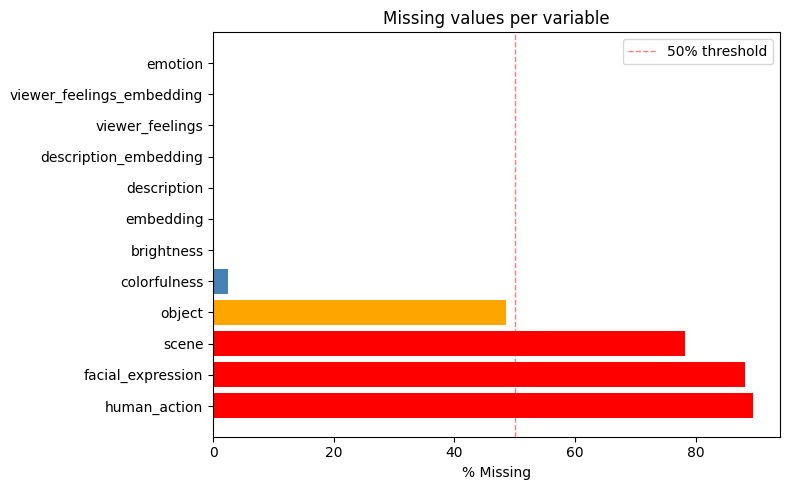

In [45]:
total = len(train_df)
null_counts = train_df.isnull().sum()
null_pct = (null_counts / total * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)

print(null_summary.to_string())

# Plot
plt.figure(figsize=(8, 5))
colors = ['red' if p > 50 else 'orange' if p > 10 else 'steelblue' 
          for p in null_summary['null_pct']]
plt.barh(null_summary.index, null_summary['null_pct'], color=colors)
plt.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
plt.xlabel('% Missing')
plt.title('Missing values per variable')
plt.legend()
plt.tight_layout()
plt.show()

Since most of the samples are missing facial_expression, human_action and scence - we'll consider leaving these variables out of the analysis. 

emotion
contentment    103
awe            102
amusement      101
sadness        101
anger          100
fear           100
excitement      97
disgust         96
Name: count, dtype: int64


<Axes: xlabel='emotion'>

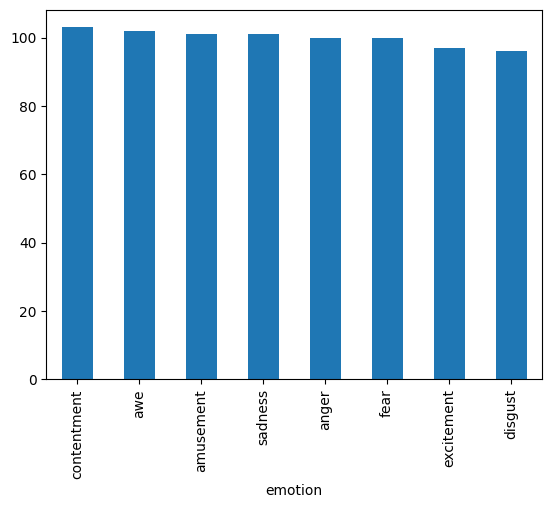

In [46]:
# emotion distribution to see if there is a class imbalance
emotion_counts = train_df['emotion'].value_counts()
print(emotion_counts)
emotion_counts.plot(kind='bar')

# Data Preprocessing Plan 
1. Numeric variables: brightness, colorfulness; standarize and fill nulls using median
2. Category variables: emotion; label encoding
3. Text variables: description, viewer_feelings, object; tfidf

## Numerics Variables

Correlation between brightness and colorfulness: 0.23


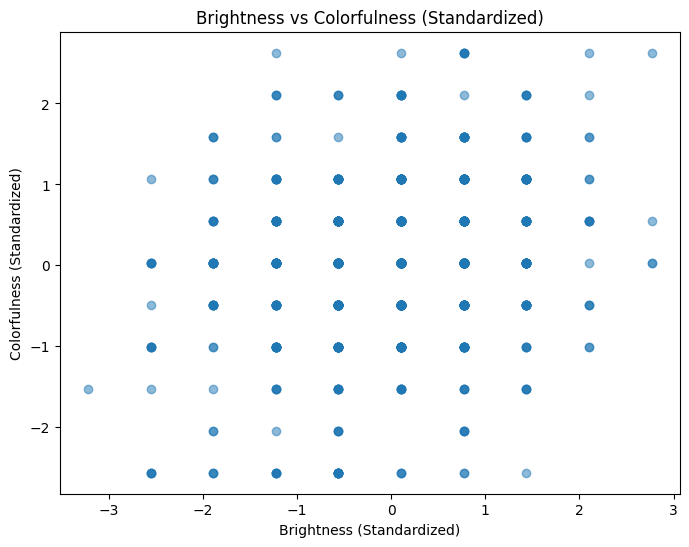

In [14]:
train_df.describe()

# Impute the few missing numeric values with median (preprocessing hasn't run yet)
brightness_col = train_df['brightness'].fillna(train_df['brightness'].median())
colorfulness_col = train_df['colorfulness'].fillna(train_df['colorfulness'].median())
X_numeric = np.column_stack([brightness_col, colorfulness_col])

# Standardize inline
scaler_eda = StandardScaler()
X_numeric_scaled = scaler_eda.fit_transform(X_numeric)

print(f"Correlation between brightness and colorfulness: {np.corrcoef(X_numeric_scaled[:, 0], X_numeric_scaled[:, 1])[0, 1]:.2f}")

# correlate brightness and colorfulness
plt.figure(figsize=(8, 6))
plt.scatter(X_numeric_scaled[:, 0], X_numeric_scaled[:, 1], alpha=0.5)
plt.title('Brightness vs Colorfulness (Standardized)')
plt.xlabel('Brightness (Standardized)')
plt.ylabel('Colorfulness (Standardized)')
plt.show()

We see a low correlation between brightness and colorfulness, suggesting each holds unique information.

## Labeling emotion - target variable

In [ ]:
# Encode emotion labels inline
le_eda = LabelEncoder()
target = le_eda.fit_transform(train_df['emotion'])
emotion_names_eda = le_eda.classes_

## Text Variables - TFIDF

In [ ]:
# TODO: hyperparameter tuning - how many max features to select per variable?

In [ ]:
def prefix_text(text, prefix):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    words = [w for w in text.lower().split() if w not in ENGLISH_STOP_WORDS]
    return ' '.join(f"{prefix}_{w}" for w in words)

def prefix_object_list(text, prefix):
    """Handle object column which contains list strings like ['Tree', 'Plant']"""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    try:
        items = ast.literal_eval(text)  # parse ['Tree', 'Plant'] -> ['Tree', 'Plant']
        if isinstance(items, list):
            words = [item.lower().strip() for item in items if item.strip()]
            return ' '.join(f"{prefix}_{w}" for w in words)
    except:
        pass
    # fallback: treat as plain text
    return prefix_text(text, prefix)

train_df['combined_text'] = (
    train_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    train_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    train_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

tfidf_combined = TfidfVectorizer(max_features=80)
combined_matrix = tfidf_combined.fit_transform(train_df['combined_text'])

print(f"Combined TF-IDF matrix shape: {combined_matrix.shape}")
print(f"Sample features: {tfidf_combined.get_feature_names_out()[:20]}")

Combined TF-IDF matrix shape: (800, 80)
Sample features: ['desc_backdrop' 'desc_background' 'desc_black' 'desc_blue'
 'desc_colorful' 'desc_dark' 'desc_features' 'desc_green' 'desc_hair'
 'desc_holding' 'desc_image' 'desc_large' 'desc_man' 'desc_person'
 'desc_red' 'desc_setting' 'desc_shirt' 'desc_shows' 'desc_sky'
 'desc_small']


In [ ]:
# present the first 5 rows of combined_matrix
combined_df = pd.DataFrame(combined_matrix[:5].toarray(), columns=tfidf_combined.get_feature_names_out())
print(combined_df.head())
print(combined_df.columns)

In [ ]:
# TODO: apply all transformations to the test set as well,
#       using the same encoders and scalers fitted on the training set

## PCA

In [ ]:
# TODO: decide on the PCA dimensionality reduction for visualization and modeling - how many components to keep?

In [ ]:
svd_combined = TruncatedSVD(n_components=80)
combined_pca = svd_combined.fit_transform(combined_matrix)
print(f"Combined PCA shape: {combined_pca.shape}")

In [ ]:
# --- PLOT 1: Explained Variance Ratio (Scree Plot) ---
def plot_variance(pca_model, title=''):
    indv_var = pca_model.explained_variance_ratio_
    cum_var = np.cumsum(indv_var)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(indv_var) + 1), indv_var, marker='o', color='purple', label='Individual Component', linewidth=2)
    plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='orange', label='Cumulative', linewidth=2)
    plt.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7, label='85% threshold')

    plt.title(f"Explained Variance Ratio - {title}")
    plt.xlabel("Number of Components")
    plt.ylabel("Explained Variance Ratio")
    plt.xticks(range(1, len(indv_var) + 1))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  {title}: {cum_var[-1]:.1%} total variance explained with {len(indv_var)} components")


# --- PLOT 2: 3D Projection ---
def plot_3d_pca(X_pca, labels, emotion_names, title=''):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    cmap = plt.cm.get_cmap('tab10', len(emotion_names))
    for i, name in enumerate(emotion_names):
        mask = labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                   c=[cmap(i)], label=name, alpha=0.6, s=20)

    ax.set_title(f"3D PCA Projection - {title}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.view_init(elev=10, azim=-95)
    ax.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


# --- PLOT 3: 2D Projection ---
def plot_2d_pca(X_pca, labels, emotion_names, title=''):
    plt.figure(figsize=(8, 6))

    cmap = plt.cm.get_cmap('tab10', len(emotion_names))
    for i, name in enumerate(emotion_names):
        mask = labels == i
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cmap(i)], label=name, alpha=0.8, s=20)

    plt.title(f"2D PCA Projection - {title}")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


# --- Check variance explained for all SVD models ---
print("=== Variance Explained Summary ===")
for svd_model, name in [
    # (svd_desc,   'Description (40 components)'),
    # (svd_feel,   'Viewer Feelings (40 components)'),
    # (svd_obj,    'Object (15 components)'),
    # (svd_scene,  'Scene (5 components)'),
    # (svd_action, 'Action (5 components)'),
    (svd_combined, 'All Text Combined (80 components)')
]:
    plot_variance(svd_model, title=name)


In [ ]:
## PCA on All Metadata text Features Combined
# --- 2D and 3D scatter colored by emotion ---
y = target
emotion_names = le_eda.classes_
plot_2d_pca(combined_pca, y, emotion_names, title='All Text Metadata Features')
plot_3d_pca(combined_pca, y, emotion_names, title='All Text Metadata Features')

In [ ]:
# these are the PCA results after excluding facial exression, scene and human_action, which had a lot of missing values and didn't add much variance 
# TODO: explain this change and the rationale behind it, and how it affected the PCA results

## K-MEANS / K-MODES

In [ ]:
# TODO: debug the k-means clustering and ARI calculation, and add visualizations of the clusters in PCA space

# Modeling 

## 1. Tabular model
Steps: 
1. Choose 2-3 potential models
2. Use cross validation on the training set - use GridSearchCV to do hyperparameter tunning
3. Assess feature importance
4. Evaluate performance of best model on the test set and interpret

In [ ]:
# Variables to include:
# - brightness
# - colorfulness
# - features from the text columns (after TF-IDF - description, viewer_feelings, object)

In [ ]:
warnings.filterwarnings('ignore')

# ── 1. Assemble feature matrix ──────────────────────────────────────────────
X_train = hstack([combined_matrix, csr_matrix(X_numeric_scaled)])
le = le_eda
y_train = target
emotion_names = le_eda.classes_
print(f"Feature matrix shape: {X_train.shape}")

# ── 2. Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression (L1)': LogisticRegression(
        penalty='l1', solver='saga', max_iter=1000, random_state=42
    ),
    'Logistic Regression (L2)': LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

# ── 3. Cross-validation ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    # Accuracy
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Precision and Recall (macro = equal weight per class)
    precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision_macro')
    recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall_macro')
    
    # AUC - needs probability estimates (roc_auc_ovr = one vs rest for multiclass)
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc_ovr')
    
    results[name] = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'auc': auc,
    }
    print(f"\n{name}")
    for metric, scores in results[name].items():
        print(f"  {metric:22s} mean={scores.mean():.3f}  std={scores.std():.3f}")

Feature matrix shape: (800, 82)

Logistic Regression (L1)
  accuracy               mean=0.584  std=0.035
  precision              mean=0.590  std=0.040
  recall                 mean=0.585  std=0.035
  auc                    mean=0.904  std=0.013

Logistic Regression (L2)
  accuracy               mean=0.588  std=0.031
  precision              mean=0.591  std=0.034
  recall                 mean=0.588  std=0.031
  auc                    mean=0.912  std=0.009

Random Forest
  accuracy               mean=0.576  std=0.031
  precision              mean=0.583  std=0.030
  recall                 mean=0.577  std=0.031
  auc                    mean=0.900  std=0.013

Gradient Boosting
  accuracy               mean=0.560  std=0.039
  precision              mean=0.564  std=0.039
  recall                 mean=0.561  std=0.040
  auc                    mean=0.883  std=0.015


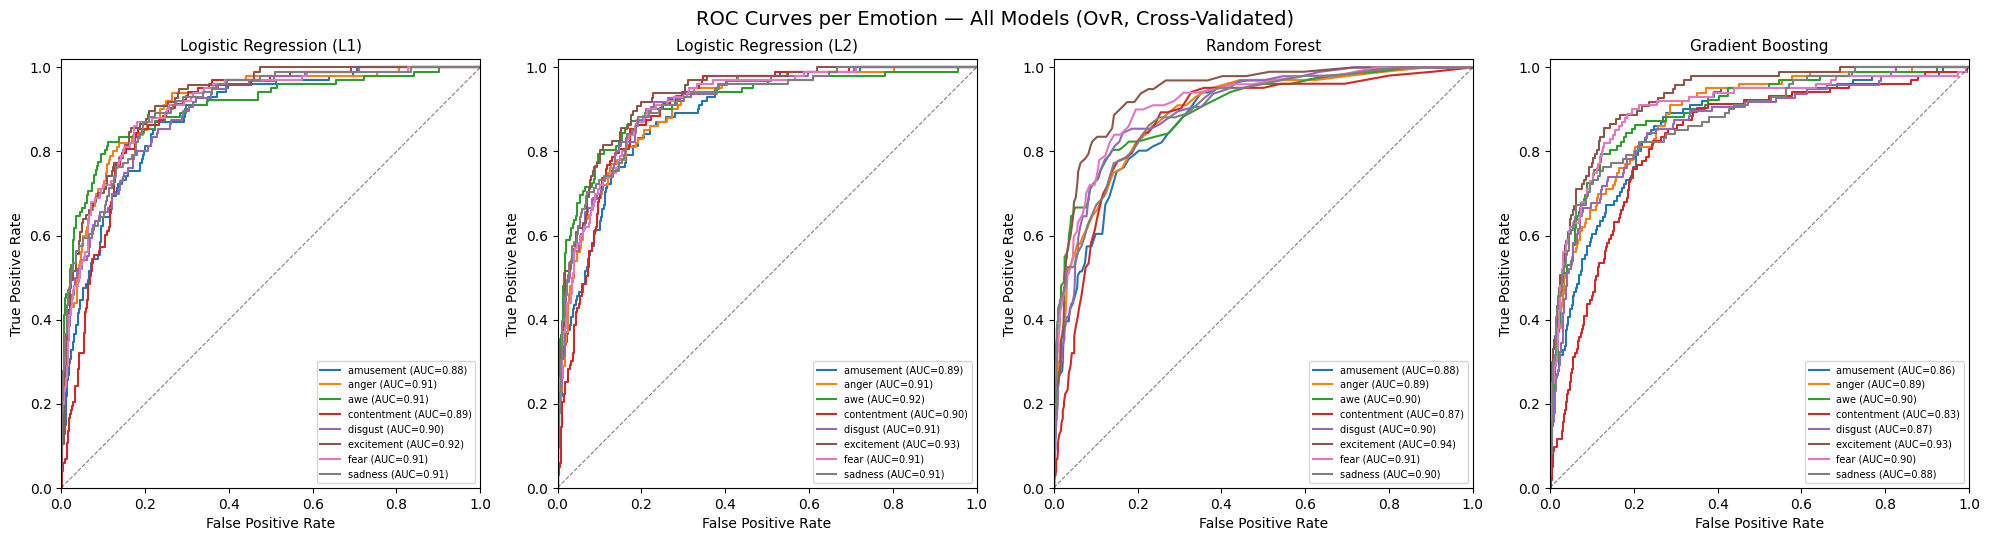

In [ ]:
# plot ROC curves for each model -
# one panel for each model
# represent each emotion class as a separate curve in the panel, and include a legend to identify which curve corresponds to which emotion class


# Binarize labels for OvR ROC (shape: n_samples x n_classes)
y_bin = label_binarize(y_train, classes=range(len(emotion_names)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    # Get probability estimates via cross-validation
    y_prob = cross_val_predict(
        model, X_train, y_train, cv=cv, method='predict_proba'
    )
    # y_prob shape: (n_samples, n_classes)
    
    # Plot one ROC curve per emotion
    for i, emotion in enumerate(emotion_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f"{emotion} (AUC={roc_auc:.2f})")
    
    # Random chance line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# Hide the last empty panel if models < 8
for j in range(len(models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves per Emotion — All Models (OvR, Cross-Validated)', fontsize=14)
plt.tight_layout()
plt.show()

                          accuracy  precision  recall    auc
Logistic Regression (L1)     0.584      0.590   0.585  0.904
Logistic Regression (L2)     0.588      0.591   0.588  0.912
Random Forest                0.576      0.583   0.577  0.900
Gradient Boosting            0.560      0.564   0.561  0.883


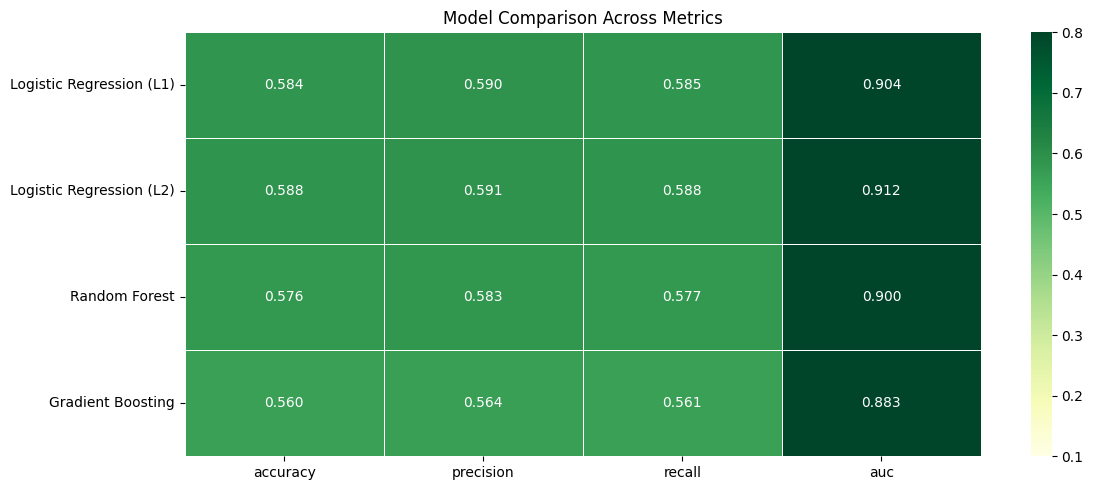

In [37]:
summary = pd.DataFrame({
    name: {metric: scores.mean() for metric, scores in metrics.items()}
    for name, metrics in results.items()
}).T.round(3)

print(summary)

plt.figure(figsize=(12, 5))
sns.heatmap(summary, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, vmin=0.1, vmax=0.8)
plt.title('Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

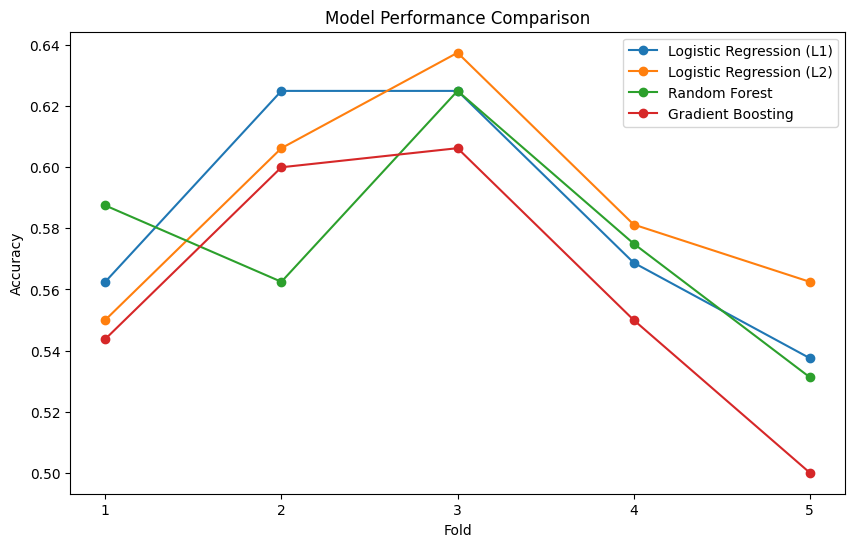

In [33]:
# plot the results as score per fold for each model (colorcode the models and add a legend)
plt.figure(figsize=(10, 6))
for name, scores in results.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)
plt.xlabel('Fold')
plt.xticks(range(1, 6))
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

Step 1 — GridSearchCV on the best model

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV accuracy: 0.588


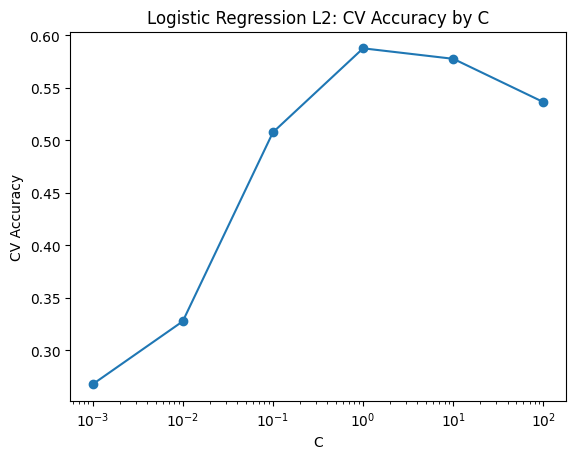

In [ ]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best C: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

# See how all C values performed
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.plot(param_grid['C'], cv_results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('CV Accuracy')
plt.title('Logistic Regression L2: CV Accuracy by C')
plt.show()

Step 2 — Feature importance (differs by model):

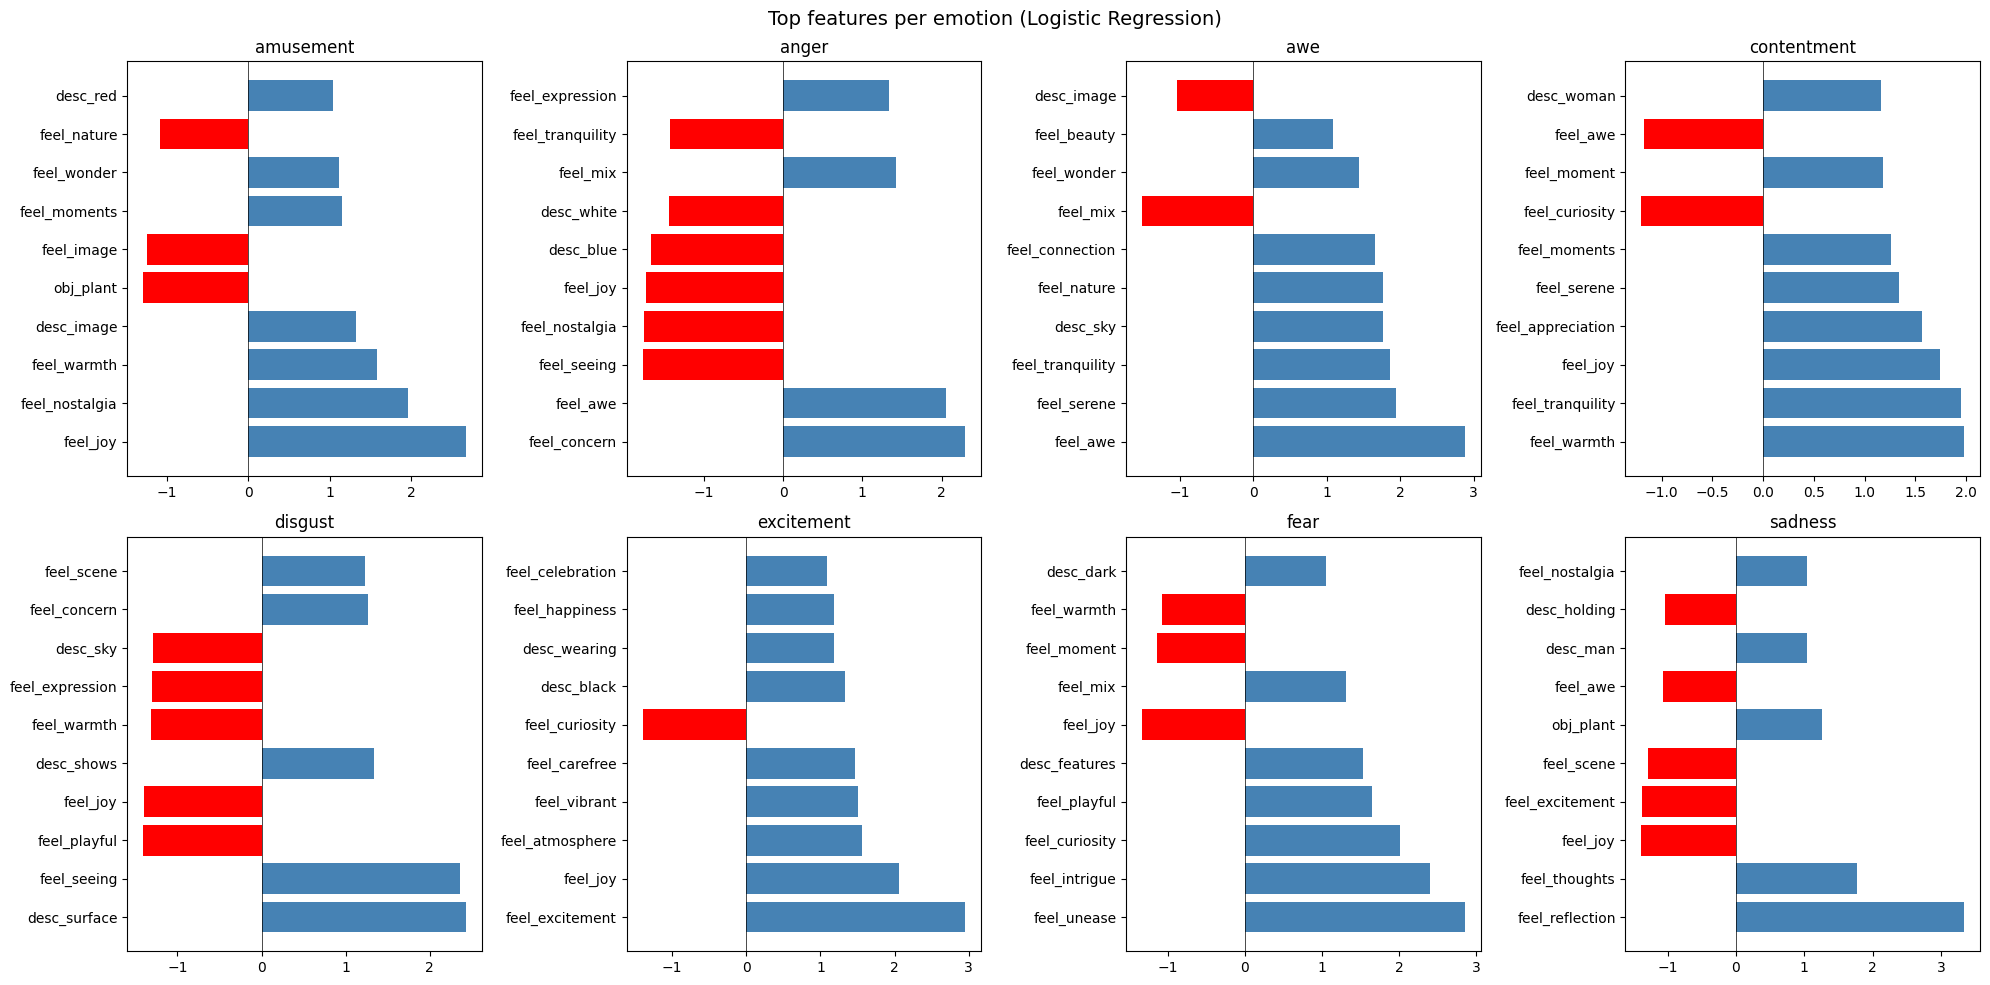

In [ ]:
# Get feature names (TF-IDF + numeric)
feature_names = list(tfidf_combined.get_feature_names_out()) + ['brightness', 'colorfulness']

# ── For Logistic Regression ──────────────────────────────────────────────────
# coef_ shape is (n_classes, n_features) - one row per emotion
coef_df = pd.DataFrame(
    best_model.coef_,
    index=emotion_names,
    columns=feature_names
)

# Plot top N features per emotion
n_top = 10
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotion_names):
    top_features = coef_df.loc[emotion].abs().nlargest(n_top)
    colors = ['red' if coef_df.loc[emotion, f] < 0 else 'steelblue' for f in top_features.index]
    axes[i].barh(top_features.index, coef_df.loc[emotion, top_features.index], color=colors)
    axes[i].set_title(emotion)
    axes[i].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Top features per emotion (Logistic Regression)', fontsize=14)
plt.tight_layout()
plt.show()


--- amusement ---


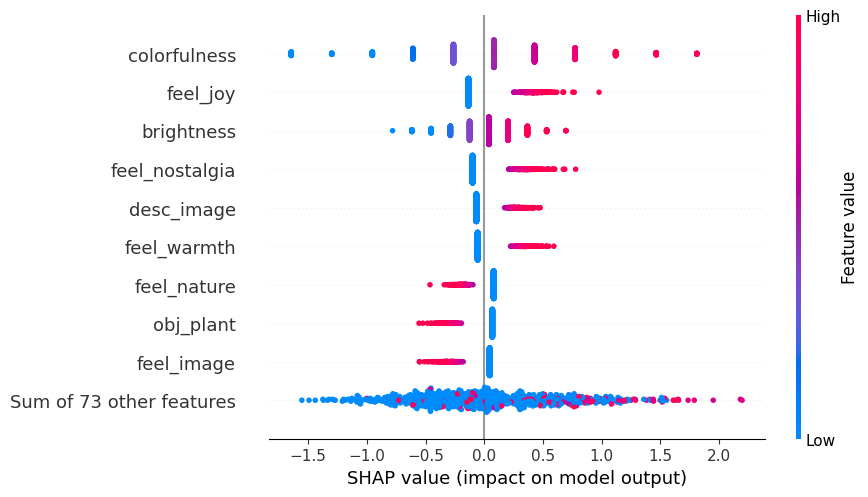


--- anger ---


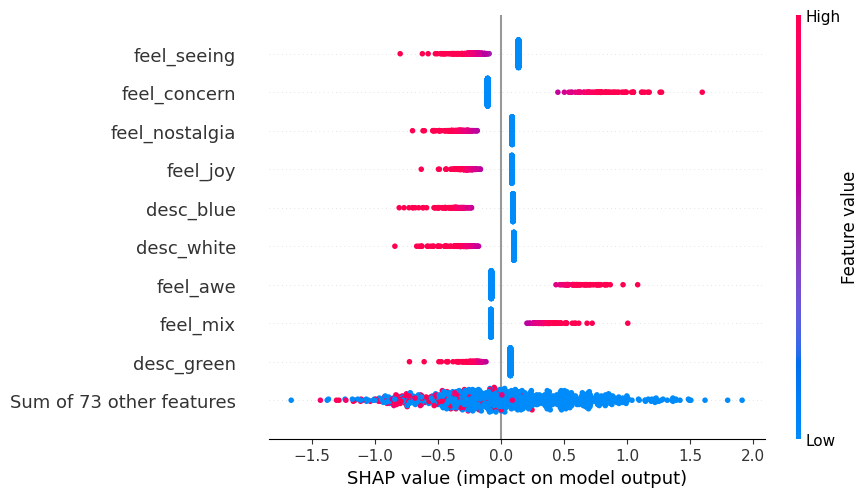


--- awe ---


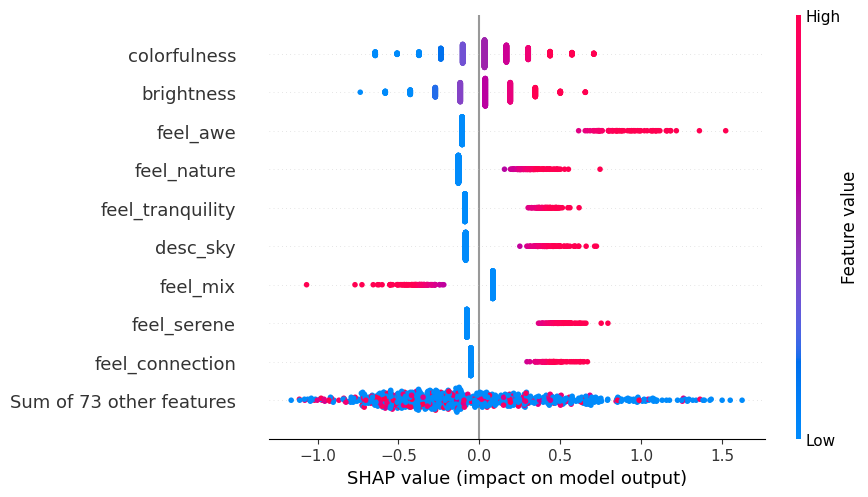


--- contentment ---


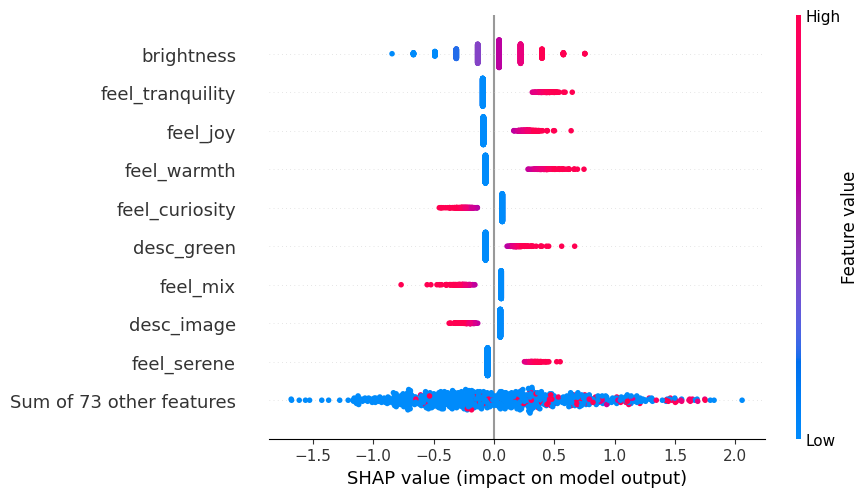


--- disgust ---


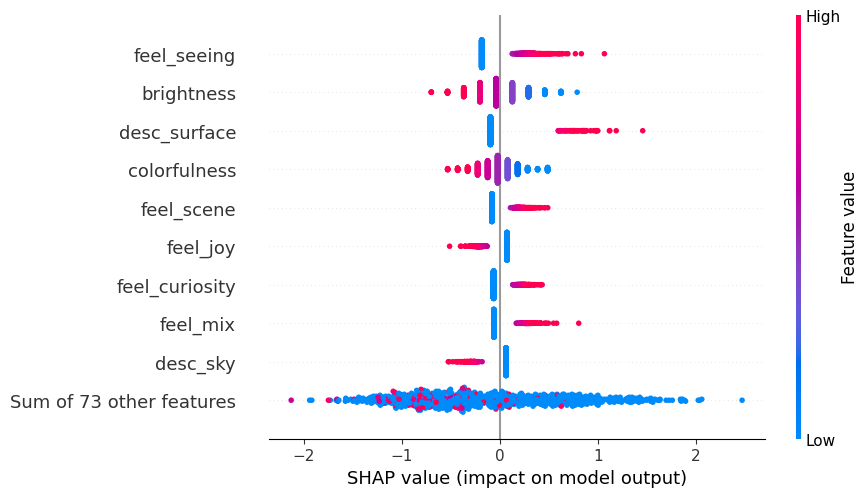


--- excitement ---


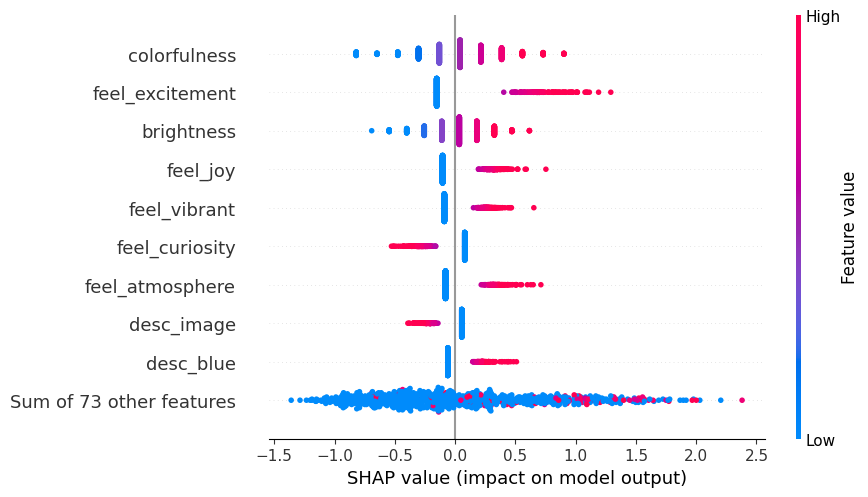


--- fear ---


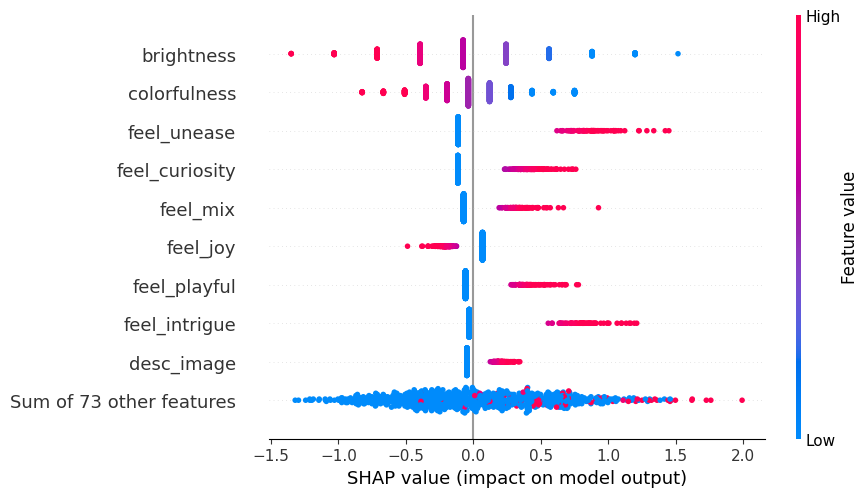


--- sadness ---


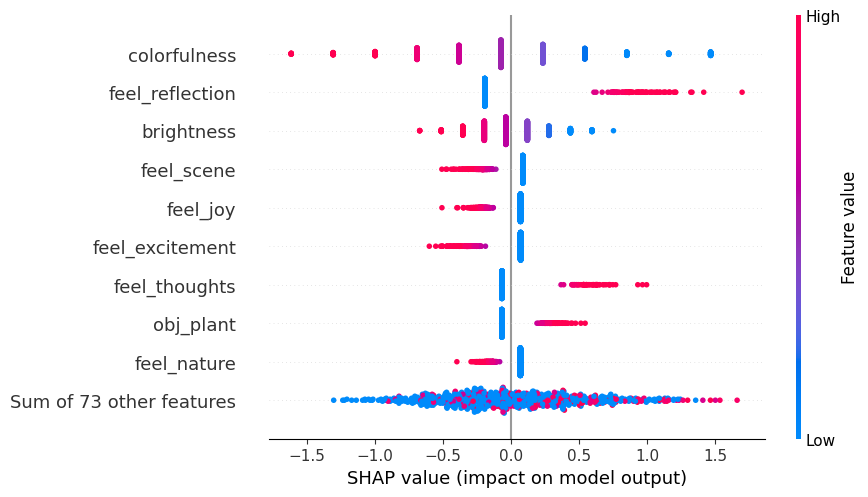

In [ ]:
# Convert to DataFrame with feature names BEFORE passing to SHAP
X_train_dense = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

explainer = shap.LinearExplainer(best_model, X_train_dense)
shap_values = explainer(X_train_dense)

# Now plots will show actual feature names like desc_woman, feel_happy etc.
for i, emotion in enumerate(emotion_names):
    print(f"\n--- {emotion} ---")
    shap.plots.beeswarm(shap_values[:, :, i], max_display=10, show=True)

Choosing the most important features using SHAP
- We used cross validation to determine the best N(features) - that resulted in the maximum AUC 

             feature  mean_abs_shap
0       colorfulness       0.239882
1         brightness       0.190646
2           feel_joy       0.134301
3    feel_excitement       0.085618
4           feel_mix       0.084688
5         desc_image       0.082846
6    feel_reflection       0.081922
7        feel_seeing       0.081895
8     feel_nostalgia       0.081166
9     feel_curiosity       0.080050
10       feel_nature       0.077495
11      feel_concern       0.077035
12          feel_awe       0.075898
13  feel_tranquility       0.073175
14       feel_warmth       0.065898
15        feel_scene       0.059012
16       feel_unease       0.057781
17       feel_serene       0.055367
18          desc_sky       0.054557
19      desc_surface       0.052017


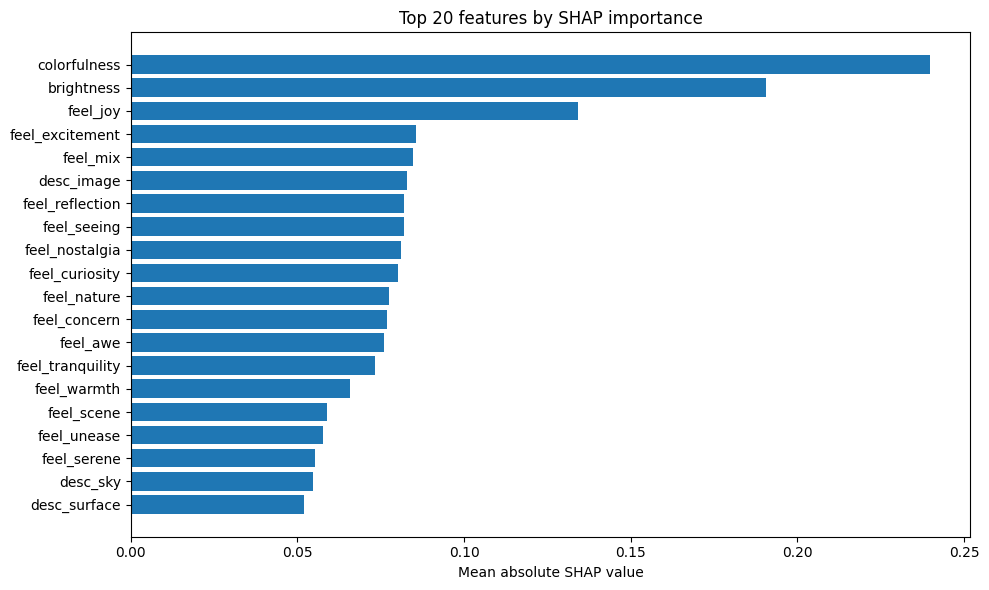

Top  10 features — AUC mean=0.838  std=0.019
Top  20 features — AUC mean=0.891  std=0.015
Top  30 features — AUC mean=0.902  std=0.012
Top  40 features — AUC mean=0.908  std=0.011
Top  50 features — AUC mean=0.912  std=0.009
Top  60 features — AUC mean=0.914  std=0.008
Top  82 features — AUC mean=0.912  std=0.009


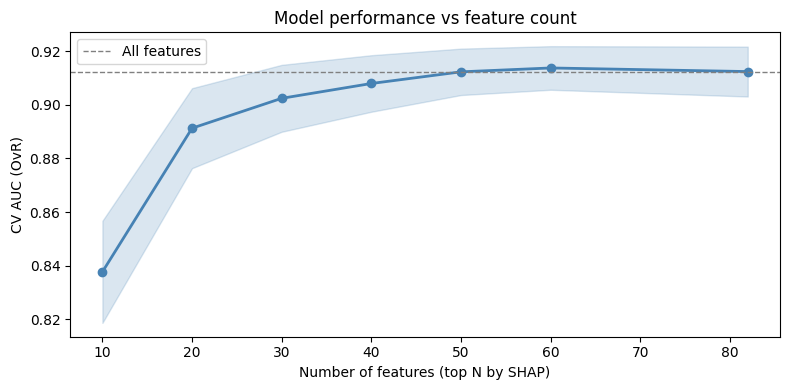

Best cutoff: top 60 features
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV AUC: 0.914


In [39]:
# ── 1. Get mean absolute SHAP per feature (across all emotions) ──────────────
# shap_values.values shape: (n_samples, n_features, n_classes)
mean_shap_per_feature = np.abs(shap_values.values).mean(axis=(0, 2))  
# average over samples AND classes → shape: (n_features,)

# Create a ranked dataframe
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_shap_per_feature
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance_df.head(20))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['feature'][:20][::-1], 
         shap_importance_df['mean_abs_shap'][:20][::-1])
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 features by SHAP importance')
plt.tight_layout()
plt.show()

# ── 2. Try different feature cutoffs using CV ────────────────────────────────
# Instead of arbitrarily picking top-N, test several thresholds

cutoffs = [10, 20, 30, 40, 50, 60, 82]  # 82 = all features
cutoff_results = {}

for n in cutoffs:
    # Select top N feature indices
    top_n_features = shap_importance_df['feature'][:n].tolist()
    top_n_idx = [feature_names.index(f) for f in top_n_features]
    
    # Subset the feature matrix
    X_subset = X_train_dense.iloc[:, top_n_idx]
    
    # CV with best model
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_subset, y_train, cv=cv, scoring='roc_auc_ovr'
    )
    cutoff_results[n] = scores
    print(f"Top {n:3d} features — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── 3. Plot performance vs number of features ────────────────────────────────
means = [cutoff_results[n].mean() for n in cutoffs]
stds = [cutoff_results[n].std() for n in cutoffs]

plt.figure(figsize=(8, 4))
plt.plot(cutoffs, means, marker='o', color='steelblue', linewidth=2)
plt.fill_between(cutoffs, 
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='steelblue')
plt.axhline(means[-1], color='gray', linestyle='--', linewidth=1, label='All features')
plt.xlabel('Number of features (top N by SHAP)')
plt.ylabel('CV AUC (OvR)')
plt.title('Model performance vs feature count')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Select best cutoff and retrain final model ────────────────────────────
best_n = cutoffs[np.argmax(means)]
print(f"Best cutoff: top {best_n} features")

top_features_final = shap_importance_df['feature'][:best_n].tolist()
top_idx_final = [feature_names.index(f) for f in top_features_final]

X_train_final = X_train_dense.iloc[:, top_idx_final]

# Retrain with GridSearchCV on reduced feature set
grid_search_final = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc_ovr', verbose=1
)
grid_search_final.fit(X_train_final, y_train)
best_model_final = grid_search_final.best_estimator_

print(f"Best C: {grid_search_final.best_params_}")
print(f"Best CV AUC: {grid_search_final.best_score_:.3f}")

Step 3 — Evaluate on test set:

In [ ]:
# Apply the SAME preprocessing to test_df
test_df[text_columns] = test_df[text_columns].fillna('')
test_df['combined_text'] = (
    test_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    test_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    test_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

# Use transform (NOT fit_transform) on test data
test_tfidf = tfidf_combined.transform(test_df['combined_text'])
test_numeric = scaler.transform(test_df[['brightness', 'colorfulness']].fillna(
    train_df[['brightness', 'colorfulness']].median()
))
X_test = hstack([test_tfidf, csr_matrix(test_numeric)])
y_test = le_eda.transform(test_df['emotion'])

# Evaluate
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=emotion_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

In [ ]:
# TODO: after selecting the best model, fit it on the entire training set and evaluate on the test set, 
#       and inverse transform the predicted labels to the original emotion names for interpretation
predicted_emotions = le_eda.inverse_transform(model.predict(X_test))

## 2. Embedding model

### Applying PCA on the embedded variables

In [ ]:
# > hint: use Exercise V LassoCV and LogisticRegressionCV for feature selection and modeling